In [1]:
#!pip install langdetect
#pip install deep_translator
#!pip install --upgrade numpy
#!pip install spacy
#!pip install --upgrade pip
#!pip install --upgrade scapy
#!pip install spacy
#%pip install numpy

In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [3]:
#read the xlsx file using pandas library
df=pd.read_excel("dataset -P543 (1).xlsx")
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [4]:
df.shape

(1440, 3)

In [5]:
#perform an exploratory data analysis to understand its structure and content
print("Data types:")
print(df.dtypes)
print("Null values:")
print(df.isnull().sum())   
df["rating"].value_counts()

Data types:
title     object
rating     int64
body      object
dtype: object
Null values:
title     0
rating    0
body      0
dtype: int64


rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

In [6]:
#The title column along with the body column,contains the text data that describes the product.For an nlp model, both of these columns would be used 
#as input features to predict the rating. the title provide a coincise summary ,while the body provides a more detailed review. 
#Combine the title and body into a single single feature

df["text"]=df["title"].fillna(' ') + ' ' + df["body"].fillna(' ')
df["text"]

0       Horrible product Very disappointed with the ov...
1       Camera quality is not like 48 megapixel Camera...
2       Overall Got the mobile on the launch date,Batt...
3       A big no from me 1. It doesn't work with 5.0GH...
4       Put your money somewhere else Not worth buying...
                              ...                        
1435                    Excellent mobile Excellent mobile
1436    Never expected from samsung All over mobile pe...
1437    Good value for money Battery life is good but ...
1438    Unreal and whitish display It's a very bad pro...
1439    Beast of the best. The phone is a real beast t...
Name: text, Length: 1440, dtype: object

In [7]:
df

,title,rating,body,text
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...
...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Excellent mobile Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Never expected from samsung All over mobile pe...
1437,Good value for money,5,Battery life is good but camera clarity could ...,Good value for money Battery life is good but ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Unreal and whitish display It's a very bad pro...


In [8]:
df = df.drop(columns = 'title')
df = df.drop(columns = 'body')
df

,rating,text
0,1,Horrible product Very disappointed with the ov...
1,3,Camera quality is not like 48 megapixel Camera...
2,4,"Overall Got the mobile on the launch date,Batt..."
3,1,A big no from me 1. It doesn't work with 5.0GH...
4,1,Put your money somewhere else Not worth buying...
...,...,...
1435,5,Excellent mobile Excellent mobile
1436,1,Never expected from samsung All over mobile pe...
1437,5,Good value for money Battery life is good but ...
1438,1,Unreal and whitish display It's a very bad pro...


In [9]:
#Analyzing the rating column

df["rating"].value_counts()

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

In [10]:
#Normalization
# Convert all words to lowercase
df["text"] = df["text"].str.lower()

# Print the words

df


,rating,text
0,1,horrible product very disappointed with the ov...
1,3,camera quality is not like 48 megapixel camera...
2,4,"overall got the mobile on the launch date,batt..."
3,1,a big no from me 1. it doesn't work with 5.0gh...
4,1,put your money somewhere else not worth buying...
...,...,...
1435,5,excellent mobile excellent mobile
1436,1,never expected from samsung all over mobile pe...
1437,5,good value for money battery life is good but ...
1438,1,unreal and whitish display it's a very bad pro...


In [11]:
# removing punctuations
import string
df['text'] = df['text'].str.replace('[{}]'.format(string.punctuation), '')
df

,rating,text
0,1,horrible product very disappointed with the ov...
1,3,camera quality is not like 48 megapixel camera...
2,4,"overall got the mobile on the launch date,batt..."
3,1,a big no from me 1. it doesn't work with 5.0gh...
4,1,put your money somewhere else not worth buying...
...,...,...
1435,5,excellent mobile excellent mobile
1436,1,never expected from samsung all over mobile pe...
1437,5,good value for money battery life is good but ...
1438,1,unreal and whitish display it's a very bad pro...


In [12]:
# removing stopwords
from nltk.corpus import stopwords

# load stopwords
stop_words = set(stopwords.words('english'))

# keep the word 'not'
stop_words.discard('not')              # Normally stopwords remove words like:is, the, was, are, not .But “not” is important for sentiment.
                                        #this product is not good
# remove stopwords from text
df['text'] = df['text'].apply(lambda x: " ".join(
    [word for word in x.split() if word not in stop_words]
))

# show dataframe
df.head()

,rating,text
0,1,horrible product disappointed overall performa...
1,3,camera quality not like 48 megapixel camera qu...
2,4,"overall got mobile launch date,battery must ap..."
3,1,big 1. work 5.0ghz wifi frequency. 2.4ghz old ...
4,1,put money somewhere else not worth buying....f...


In [13]:
# apply lemmatization
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['text'] = df['text'].apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()]))
df

,rating,text
0,1,horrible product disappointed overall performa...
1,3,camera quality not like 48 megapixel camera qu...
2,4,"overall got mobile launch date,battery must ap..."
3,1,big 1. work 5.0ghz wifi frequency. 2.4ghz old ...
4,1,put money somewhere else not worth buying....f...
...,...,...
1435,5,excellent mobile excellent mobile
1436,1,never expected samsung mobile performance poor...
1437,5,good value money battery life good camera clar...
1438,1,"unreal whitish display bad product, highly dis..."


In [14]:
# Create a dictionary to store the word frequency
word_counts = {}
for x in df["text"]:
    # A more robust way to handle text, splitting by spaces and converting to lowercase
    for word in str(x).lower().split():
        if word:
            word_counts[word] = word_counts.get(word, 0) + 1

# The final dictionary with word counts
print(word_counts)

{'horrible': 7, 'product': 334, 'disappointed': 65, 'overall': 152, 'performance': 160, 'samsung': 663, 'camera': 853, 'quality': 603, 'not': 1352, 'like': 281, '48': 78, 'megapixel': 17, 'low': 100, 'got': 107, 'mobile': 521, 'launch': 11, 'date,battery': 1, 'must': 29, 'appreciatedcamera': 1, 'averagemobile': 1, 'average90hz': 1, 'refresh': 60, 'rate?': 1, 'u': 71, 'r': 31, 'buying': 52, 'feature': 165, 'afraid': 1, 'may': 46, 'get': 155, 'disappointed,': 2, 'normal.the': 1, 'usb': 12, 'cable': 14, 'small': 15, "lengthit's": 1, 'good': 1091, 'budget,': 6, 'return': 99, 'this,': 7, 'replacement': 50, 'available,': 5, 'hence': 13, 'choose': 18, 'wisely': 2, 'big': 65, '1.': 8, 'work': 130, '5.0ghz': 2, 'wifi': 101, 'frequency.': 2, '2.4ghz': 8, 'old': 61, 'school.2.': 1, 'pathetic': 23, '(both': 3, 'front': 74, 'back).': 2, 'forget': 6, '48mp,': 4, 'picture': 67, 'blur,': 2, 'poorer': 3, '4mp': 2, 'one.3.': 1, 'amazon': 194, 'allow': 9, 'write': 13, 'review': 113, 'sold': 9, 'stock,': 

In [15]:
#sentiment recognition using vader 
#using this nltk library we perform text preprocessing
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Instantiate the sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Create a new column for sentiment
df['compound'] = df['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
df.head()



# Classify each statement as positive or negative based on the sentiment score
df['Sentiment'] = df['compound'].apply(lambda x: 'positive' if x > 0 else 'negative')
df.head()

,rating,text,compound,Sentiment
0,1,horrible product disappointed overall performa...,-0.7650,negative
1,3,camera quality not like 48 megapixel camera qu...,-0.4956,negative
2,4,"overall got mobile launch date,battery must ap...",0.3818,positive
3,1,big 1. work 5.0ghz wifi frequency. 2.4ghz old ...,-0.4588,negative
4,1,put money somewhere else not worth buying....f...,-0.5050,negative


In [16]:
df["rating"].value_counts()

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

In [17]:
df['Sentiment'].value_counts()

Sentiment
positive    933
negative    507
Name: count, dtype: int64

In [18]:
#Label Encoding the Sentiment data
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Sentiment'] = encoder.fit_transform(df['Sentiment'])
df.head()

,rating,text,compound,Sentiment
0,1,horrible product disappointed overall performa...,-0.7650,0
1,3,camera quality not like 48 megapixel camera qu...,-0.4956,0
2,4,"overall got mobile launch date,battery must ap...",0.3818,1
3,1,big 1. work 5.0ghz wifi frequency. 2.4ghz old ...,-0.4588,0
4,1,put money somewhere else not worth buying....f...,-0.5050,0


In [19]:
Y = df["Sentiment"]
x = df['text']

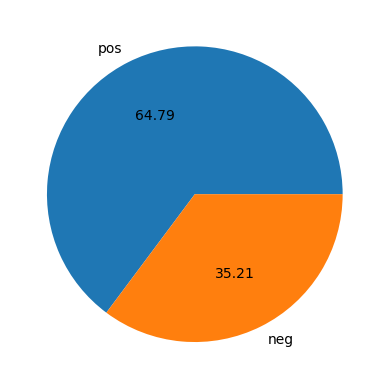

In [20]:
import matplotlib.pyplot as plt
plt.pie(df['Sentiment'].value_counts(), labels=['pos','neg'],autopct="%0.2f")
plt.show()

In [21]:
 df['Sentiment'].value_counts()

Sentiment
1    933
0    507
Name: count, dtype: int64

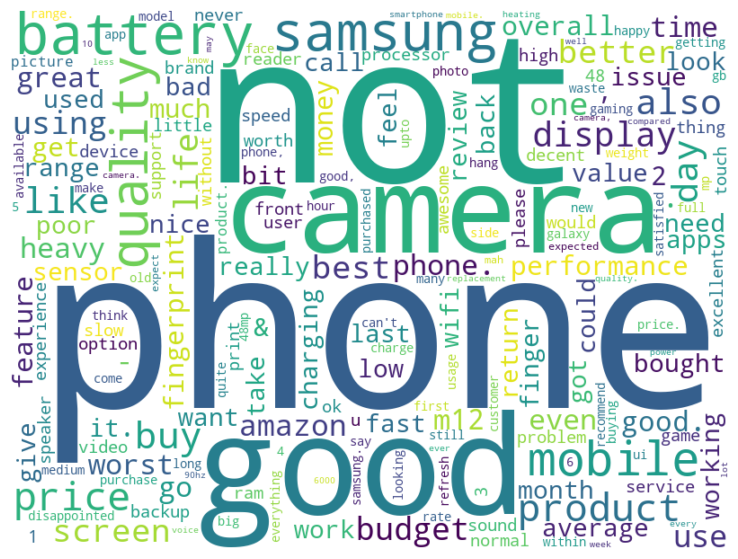

In [22]:
#Wordcloud Visualization

from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Create the word cloud
wordcloud = WordCloud(width=800, height=600, background_color="white").generate_from_frequencies(word_counts)
# Display the word cloud
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [23]:
x = df['text']
y = df['Sentiment']

In [24]:
#Train Test split

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [25]:
# Step 3: TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(x_train)   # ✅ correct
X_test_vec = vectorizer.transform(x_test)         # ✅ correct

In [26]:
print(X_test_vec)

  (0, 203)	0.08356382181544102
  (0, 212)	0.062197094081173104
  (0, 306)	0.06912113847314018
  (0, 312)	0.10663260458338385
  (0, 353)	0.10448293711896732
  (0, 382)	0.15455841641850274
  (0, 794)	0.08612235692361617
  (0, 797)	0.12340706830015305
  (0, 810)	0.11012598613858238
  (0, 923)	0.10948973917367862
  (0, 958)	0.1199136867449545
  (0, 1011)	0.09501870838058335
  (0, 1016)	0.2825009643007885
  (0, 1281)	0.09684490397701169
  (0, 1283)	0.13319476890652518
  (0, 1315)	0.29704489747832713
  (0, 1439)	0.1400894346425332
  (0, 1568)	0.12768262177847003
  (0, 1789)	0.06112810086889148
  (0, 1821)	0.10829979054215401
  (0, 1831)	0.09501870838058335
  (0, 1833)	0.12340706830015305
  (0, 1870)	0.08130703390998066
  (0, 1949)	0.12768262177847003
  (0, 2003)	0.08130703390998066
  :	:
  (286, 4505)	0.23420685849692893
  (286, 4506)	0.2957279514345313
  (286, 4904)	0.14591287115777618
  (286, 4910)	0.2093721799001607
  (287, 327)	0.16415123427872577
  (287, 497)	0.28614651503298044
  (287,

In [27]:
#1.Naive Bayes Model

In [28]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

# Model
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# Prediction
y_train_pred = nb_model.predict(X_train_vec)
y_test_pred = nb_model.predict(X_test_vec)

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Precision, Recall, F1-score
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.8741319444444444
Test Accuracy: 0.8125
Precision: 0.8270474137931035
Recall: 0.8125
F1 Score: 0.7962623869021973
Confusion Matrix:
 [[ 50  48]
 [  6 184]]


In [29]:
# 2. Logistic Regression Model

In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)   # ✅ FIXED

# Step 5: Prediction
y_train_pred = lr_model.predict(X_train_vec)
y_test_pred = lr_model.predict(X_test_vec)

# Step 6: Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.9097222222222222
Test Accuracy: 0.8125
Precision: 0.8090664219748993
Recall: 0.8125
F1 Score: 0.8079545454545455
Confusion Matrix:
 [[ 63  35]
 [ 19 171]]


In [31]:
# 3.Decision Tree

In [32]:
#from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=20,         # control overfitting
    min_samples_split=5,
    random_state=42
)

dt_model.fit(X_train_vec, y_train)

# Step 5: Prediction
y_train_pred = dt_model.predict(X_train_vec)
y_test_pred = dt_model.predict(X_test_vec)

# Step 6: Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.9401041666666666
Test Accuracy: 0.75
Precision: 0.7664506480558325
Recall: 0.75
F1 Score: 0.7546296296296295
Confusion Matrix:
 [[ 72  26]
 [ 46 144]]


In [33]:
#4. SVM

In [34]:
from sklearn.svm import SVC

# Step 4: SVM Model (Linear Kernel)
svm_model = SVC(kernel='linear',C=0.5)

svm_model.fit(X_train_vec, y_train)

# Step 5: Prediction
y_train_pred = svm_model.predict(X_train_vec)
y_test_pred = svm_model.predict(X_test_vec)

# Step 6: Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.9322916666666666
Test Accuracy: 0.8333333333333334
Precision: 0.8308005219126564
Recall: 0.8333333333333334
F1 Score: 0.8304495711328008
Confusion Matrix:
 [[ 68  30]
 [ 18 172]]


In [35]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train_vec, y_train)

# Step 5: Prediction
y_train_pred = rf_model.predict(X_train_vec)
y_test_pred = rf_model.predict(X_test_vec)

# Step 6: Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Train Accuracy: 0.9427083333333334
Test Accuracy: 0.8159722222222222
Precision: 0.8160878352552592
Recall: 0.8159722222222222
F1 Score: 0.8073758939143554
Confusion Matrix:
 [[ 58  40]
 [ 13 177]]


In [36]:
# Import
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Convert sparse matrix to array (IMPORTANT for ANN)
X_train_ann = X_train_vec.toarray()
X_test_ann = X_test_vec.toarray()

# Build ANN model
model = Sequential()

# Input + Hidden layers
model.add(Dense(128, activation='relu', input_dim=X_train_ann.shape[1]))
model.add(Dense(64, activation='relu'))

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
model.fit(X_train_ann, y_train, epochs=5, batch_size=32, validation_split=0.1)

C:\Users\Alokp\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6322 - loss: 0.6513 - val_accuracy: 0.6552 - val_loss: 0.5772
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7625 - loss: 0.4547 - val_accuracy: 0.8448 - val_loss: 0.4075
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9527 - loss: 0.1918 - val_accuracy: 0.8276 - val_loss: 0.3740
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9923 - loss: 0.0465 - val_accuracy: 0.8276 - val_loss: 0.3921
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9990 - loss: 0.0132 - val_accuracy: 0.8190 - val_loss: 0.4489


In [37]:
# Evaluate on TRAIN data
y_train_pred = model.predict(X_train_ann)
y_train_pred = (y_train_pred > 0.5).astype(int)

print("---- TRAIN PERFORMANCE ----")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1 Score:", f1_score(y_train, y_train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))


# Evaluate on TEST data
y_test_pred = model.predict(X_test_ann)
y_test_pred = (y_test_pred > 0.5).astype(int)

print("\n---- TEST PERFORMANCE ----")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
---- TRAIN PERFORMANCE ----
Accuracy: 0.9809027777777778
Precision: 0.9800266311584553
Recall: 0.990578734858681
F1 Score: 0.9852744310575636
Confusion Matrix:
 [[394  15]
 [  7 736]]
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

---- TEST PERFORMANCE ----
Accuracy: 0.84375
Precision: 0.8571428571428571
Recall: 0.9157894736842105
F1 Score: 0.8854961832061069
Confusion Matrix:
 [[ 69  29]
 [ 16 174]]


In [38]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

# -------------------------------
# 1. Naive Bayes
# -------------------------------
nb_pred = nb_model.predict(X_test_vec)

results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, nb_pred),
    "Precision": precision_score(y_test, nb_pred, average='weighted'),
    "Recall": recall_score(y_test, nb_pred, average='weighted'),
    "F1 Score": f1_score(y_test, nb_pred, average='weighted')
})

# -------------------------------
# 2. Logistic Regression
# -------------------------------
lr_pred = lr_model.predict(X_test_vec)

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred, average='weighted'),
    "Recall": recall_score(y_test, lr_pred, average='weighted'),
    "F1 Score": f1_score(y_test, lr_pred, average='weighted')
})

# -------------------------------
# 3. Decision Tree
# -------------------------------
dt_pred = dt_model.predict(X_test_vec)

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred, average='weighted'),
    "Recall": recall_score(y_test, dt_pred, average='weighted'),
    "F1 Score": f1_score(y_test, dt_pred, average='weighted')
})

# -------------------------------
# 4. Random Forest
# -------------------------------
rf_pred = rf_model.predict(X_test_vec)

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, average='weighted'),
    "Recall": recall_score(y_test, rf_pred, average='weighted'),
    "F1 Score": f1_score(y_test, rf_pred, average='weighted')
})

# -------------------------------
# 5. SVM
# -------------------------------
svm_pred = svm_model.predict(X_test_vec)

results.append({
    "Model": "SVM (Linear)",
    "Accuracy": accuracy_score(y_test, svm_pred),
    "Precision": precision_score(y_test, svm_pred, average='weighted'),
    "Recall": recall_score(y_test, svm_pred, average='weighted'),
    "F1 Score": f1_score(y_test, svm_pred, average='weighted')
})

# -------------------------------
# 6. ANN
# -------------------------------
ann_pred = model.predict(X_test_ann)
ann_pred = (ann_pred > 0.5).astype(int)

results.append({
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, ann_pred),
    "Precision": precision_score(y_test, ann_pred),
    "Recall": recall_score(y_test, ann_pred),
    "F1 Score": f1_score(y_test, ann_pred)
})

# -------------------------------
# Create DataFrame
# -------------------------------
comparison_df = pd.DataFrame(results)

# Sort by Accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

print(comparison_df)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
                 Model  Accuracy  Precision    Recall  F1 Score
5                  ANN  0.843750   0.857143  0.915789  0.885496
4         SVM (Linear)  0.833333   0.830801  0.833333  0.830450
3        Random Forest  0.815972   0.816088  0.815972  0.807376
0          Naive Bayes  0.812500   0.827047  0.812500  0.796262
1  Logistic Regression  0.812500   0.809066  0.812500  0.807955
2        Decision Tree  0.750000   0.766451  0.750000  0.754630


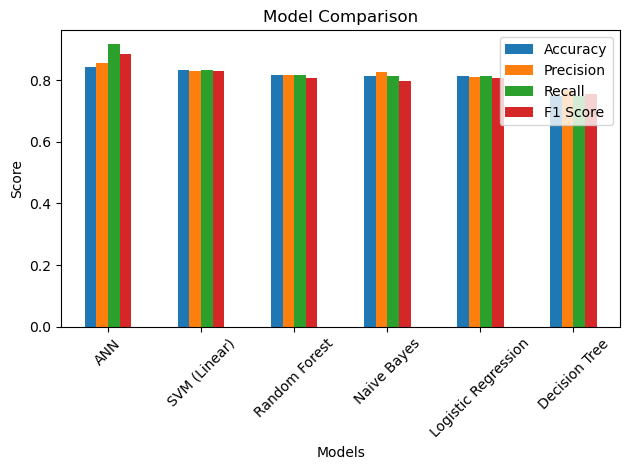

In [39]:
import matplotlib.pyplot as plt

# Assuming you already created this DataFrame
# comparison_df

# Set index as Model name
comparison_df.set_index("Model", inplace=True)

# Plot bar chart
comparison_df.plot(kind='bar')

# Labels & Title
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")

# Rotate labels for clarity
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()
plt.show()

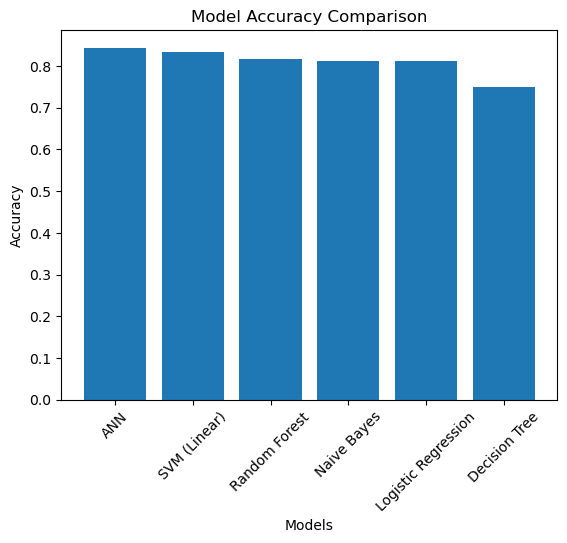

In [40]:
plt.figure()

plt.bar(comparison_df.index, comparison_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.show()

In [41]:
import pickle
X = df['text']
Y = df['Sentiment']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Step 3: TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(x_train)   # ✅ correct
X_test_vec = vectorizer.transform(x_test) 

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1063)
lr_model.fit(X_train_vec, y_train)   

pickle.dump(lr_model, open("sentiment_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("✅ Model trained correctly!")

✅ Model trained correctly!


### 